In [1]:
!git clone https://github.com/hani-rahmoune/pharma-safety-lakehouse.git
%cd pharma-safety-lakehouse
!pip install -r requirements.txt

Cloning into 'pharma-safety-lakehouse'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 79 (delta 26), reused 77 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 6.82 MiB | 11.02 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/pharma-safety-lakehouse
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.2/339.2 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
!python -m src.ingestion.fetch_openfda_events
!python -m src.spark_jobs.bronze_to_silver_events

2026-05-29 13:50:16,794 INFO Starting ingestion for 2024-01
2026-05-29 13:50:17,262 INFO Fetched 100 records at skip=0
2026-05-29 13:50:18,365 INFO Fetched 100 records at skip=100
2026-05-29 13:50:19,330 INFO Fetched 100 records at skip=200
2026-05-29 13:50:20,404 INFO Fetched 100 records at skip=300
2026-05-29 13:50:21,148 INFO Fetched 100 records at skip=400
2026-05-29 13:50:22,136 INFO Fetched 100 records at skip=500
2026-05-29 13:50:23,576 INFO Fetched 100 records at skip=600
2026-05-29 13:50:24,341 INFO Fetched 100 records at skip=700
2026-05-29 13:50:25,123 INFO Fetched 100 records at skip=800
2026-05-29 13:50:26,724 INFO Fetched 100 records at skip=900
2026-05-29 13:50:27,026 INFO Total records fetched for 2024-01: 1000
2026-05-29 13:50:27,681 INFO Saved 1000 records to data/bronze/openfda_events/year=2024/month=01/events.json
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 13:50:32 WARN N

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

events = pd.read_parquet("/content/pharma-safety-lakehouse/data/silver/adverse_events")
drugs  = pd.read_parquet("/content/pharma-safety-lakehouse/data/silver/drugs")
reactions = pd.read_parquet("/content/pharma-safety-lakehouse/data/silver/reactions")

print(f"silver_adverse_events: {events.shape[0]} rows, {events.shape[1]} columns")
print(f"silver_drugs:          {drugs.shape[0]} rows, {drugs.shape[1]} columns")
print(f"silver_reactions:      {reactions.shape[0]} rows, {reactions.shape[1]} columns")

silver_adverse_events: 1000 rows, 8 columns
silver_drugs:          3566 rows, 4 columns
silver_reactions:      3202 rows, 2 columns


In [3]:
print("=== silver_adverse_events ===")
display(events.head(5))
print("\n=== silver_drugs ===")
display(drugs.head(5))
print("\n=== silver_reactions ===")
display(reactions.head(5))

=== silver_adverse_events ===


,safety_report_id,country,report_date,is_serious,death,hospitalization,patient_sex,patient_age
0,23353582,US,2024-01-01,0,0.0,0.0,Female,50.0
1,23353583,US,2024-01-01,0,0.0,0.0,Male,89.0
2,23353584,US,2024-01-01,0,0.0,0.0,Male,NaN
3,23353585,CA,2024-01-01,1,1.0,0.0,Male,NaN
4,23353586,US,2024-01-01,0,0.0,0.0,Male,54.0



=== silver_drugs ===


,safety_report_id,drug_name,indication,drug_role
0,23353582,DUPIXENT,Dermatitis atopic,Suspect
1,23353582,COLESTIPOL,None,Concomitant
2,23353582,ALBUTEROL,None,Concomitant
3,23353582,GABAPENTIN,None,Concomitant
4,23353582,ATORVASTATIN,None,Concomitant



=== silver_reactions ===


,safety_report_id,reaction_name
0,23353582,Dry Eye
1,23353583,Wrong Technique In Product Usage Process
2,23353583,Injection Site Reaction
3,23353583,Injection Site Pain
4,23353584,Drug Dose Omission By Device


In [4]:
reports_with_multiple_drugs = drugs.groupby("safety_report_id").size()
print(f"Reports with 1 drug:   {(reports_with_multiple_drugs == 1).sum()}")
print(f"Reports with 2 drugs:  {(reports_with_multiple_drugs == 2).sum()}")
print(f"Reports with 3+ drugs: {(reports_with_multiple_drugs >= 3).sum()}")
print(f"\nAverage drugs per report: {reports_with_multiple_drugs.mean():.2f}")

Reports with 1 drug:   440
Reports with 2 drugs:  209
Reports with 3+ drugs: 351

Average drugs per report: 3.57


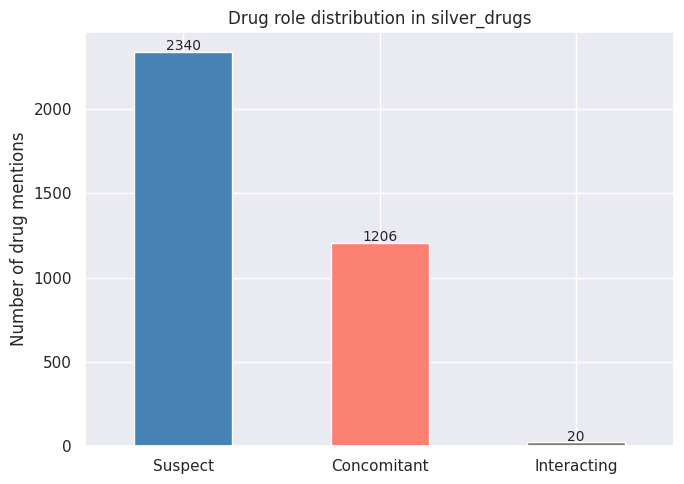

In [5]:
role_counts = drugs["drug_role"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
role_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon", "grey"])
ax.set_title("Drug role distribution in silver_drugs")
ax.set_ylabel("Number of drug mentions")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(int(bar.get_height())),
        ha="center", fontsize=10
    )
plt.tight_layout()
plt.show()

is_serious value counts:
is_serious
1    521
0    479
Name: count, dtype: int64

Null count: 0


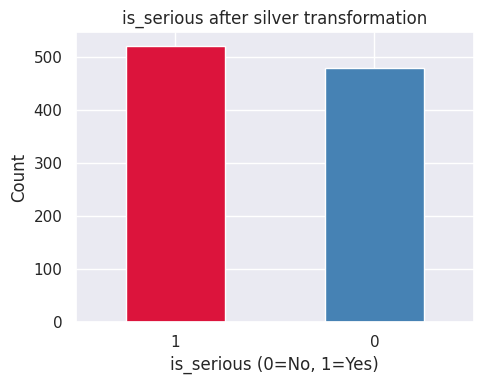

In [6]:
print("is_serious value counts:")
print(events["is_serious"].value_counts())
print(f"\nNull count: {events['is_serious'].isnull().sum()}")

fig, ax = plt.subplots(figsize=(5, 4))
events["is_serious"].value_counts().plot(kind="bar", ax=ax, color=["crimson", "steelblue"])
ax.set_title("is_serious after silver transformation")
ax.set_xlabel("is_serious (0=No, 1=Yes)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

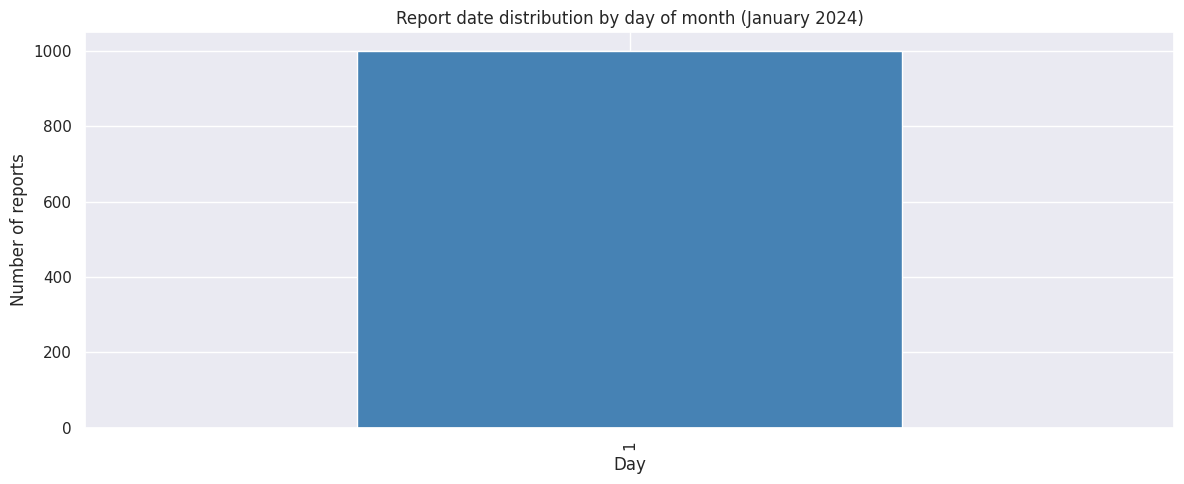

Null report_date count: 0
Date range: 2024-01-01 00:00:00 to 2024-01-01 00:00:00


In [7]:
events["report_date"] = pd.to_datetime(events["report_date"])

fig, ax = plt.subplots()
events["report_date"].dt.day.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Report date distribution by day of month (January 2024)")
ax.set_xlabel("Day")
ax.set_ylabel("Number of reports")
plt.tight_layout()
plt.show()

print(f"Null report_date count: {events['report_date'].isnull().sum()}")
print(f"Date range: {events['report_date'].min()} to {events['report_date'].max()}")

In [8]:
print("patient_sex value counts:")
print(events["patient_sex"].value_counts())
print(f"Null count: {events['patient_sex'].isnull().sum()}")

patient_sex value counts:
patient_sex
Female    492
Male      357
Name: count, dtype: int64
Null count: 151


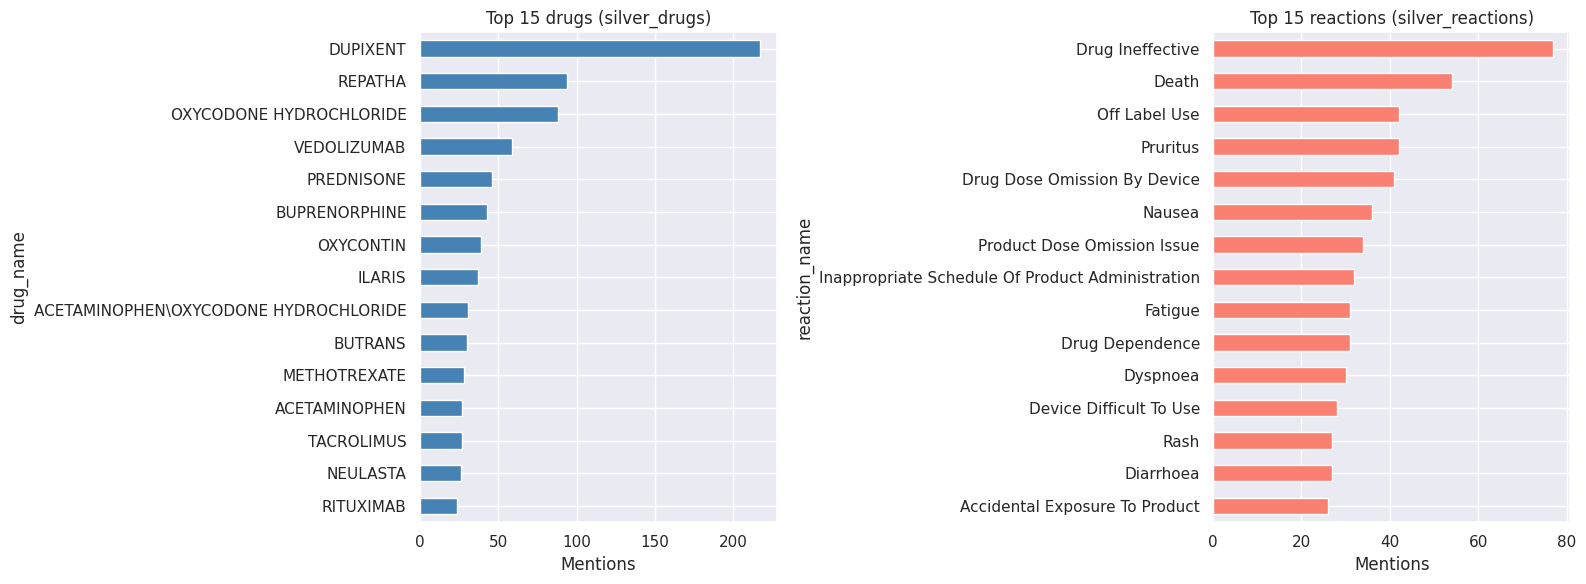

In [9]:
top_drugs = drugs["drug_name"].value_counts().head(15)
top_reactions = reactions["reaction_name"].value_counts().head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_drugs.plot(kind="barh", ax=ax1, color="steelblue")
ax1.set_title("Top 15 drugs (silver_drugs)")
ax1.set_xlabel("Mentions")
ax1.invert_yaxis()

top_reactions.plot(kind="barh", ax=ax2, color="salmon")
ax2.set_title("Top 15 reactions (silver_reactions)")
ax2.set_xlabel("Mentions")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()